# Metaheuristic Path Planning Algorithms

This notebook demonstrates the path planning algorithms based on metaheuristic optimization available in the `pathplan` library, utilizing the `metaheuropt` library.

In [1]:
import numpy as np
from pathplan.core import GridMap
from pathplan.metaheuristic import GAPlanner
from pathplan.utils import Visualizer

In [2]:
# Recreating the scenario map parameters
maze_data = np.zeros((20, 20))

# Vertical wall with an open gap
maze_data[5:15, 10] = 1.0
maze_data[10, 10] = 0.0  

# Horizontal wall with an open gap
maze_data[12, 3:17] = 1.0
maze_data[12, 8] = 0.0   

# Static block obstacles
maze_data[3:5, 3:5] = 1.0
maze_data[7:9, 15:18] = 1.0
maze_data[16:18, 5:7] = 1.0

# Define start and goal configurations (row, col indices)
start_node = (0.0, 0.0)
goal_node = (19.0, 19.0)

# Instantiate the normalized GridMap wrapper
grid_map = GridMap(maze_data)
print(f"GridMap successfully initialized with shape: {grid_map.shape}")

GridMap successfully initialized with shape: (20, 20)


Running GAPlanner...

Optimizing with: GA


Run 1/1:   0%|          | 0/200 [00:00<?, ?it/s]


========================= GLOBAL SUMMARY =========================
Algorithm    | Mean Best    | Std Dev      | Avg Time (s)
-----------------------------------------------------------------
GA           | 2.8572e+01   | 0.0000e+00   | 3.39        
-----------------------------------------------------------------
SUCCESS: Valid trajectory discovered for GA!
Total waypoints in path: 12


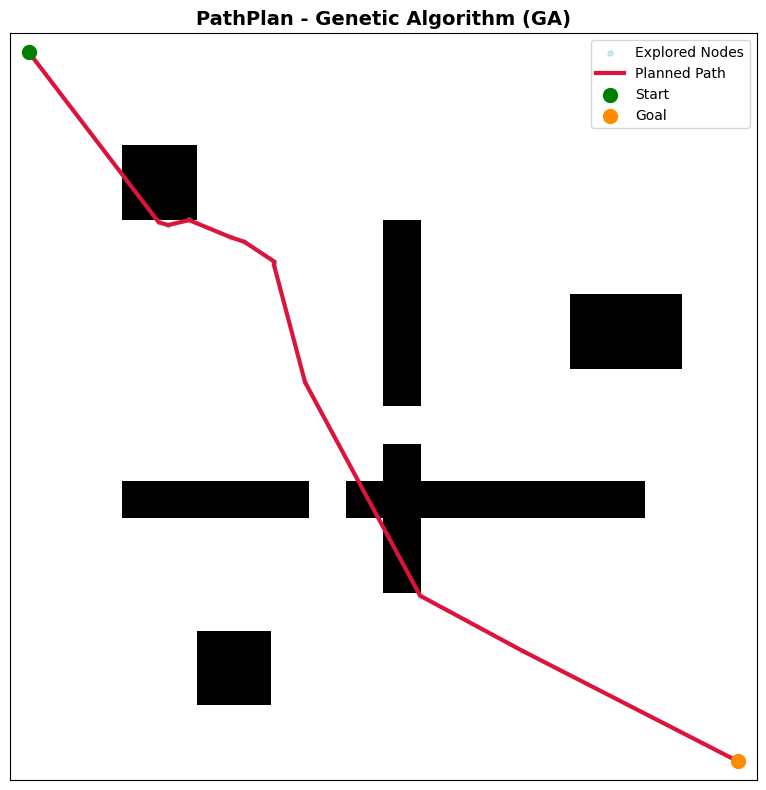

In [12]:
# Initialize the GA solver
# Metaheuristics often require more tuning. 
# We'll use 5 intermediate waypoints and a population of 50.
planner = GAPlanner(grid_map, num_waypoints=10, pop_size=100, max_iter=200)

print(f"Running GAPlanner...")
path, explored = planner.plan(start_node, goal_node)

viz = Visualizer(grid_map)

if path:
    print(f"SUCCESS: Valid trajectory discovered for GA!")
    print(f"Total waypoints in path: {len(path)}")
    
    viz.plot_path(
        path=path, 
        explored=explored, 
        title=f"PathPlan - Genetic Algorithm (GA)"
    )
else:
    print("FAILURE: GA could not find a valid path.")
    # Still plot the explored waypoints from the best (but colliding) candidate
    if explored:
        print("Showing best candidate waypoints (with collisions):")
        viz.plot_path(
            path=None, 
            explored=explored, 
            title=f"PathPlan - GA (Best Candidate with Collisions)"
        )